In [8]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
dataset_root = r"E:/Studies/Self/CCTV-Threat-Detection/Data/Smart-City-CCTV-Violence-Detection-Dataset (SCVD)/SCVD_converted"
train_dir = os.path.join(dataset_root, "Train")
test_dir = os.path.join(dataset_root, "Test")

classes = ["Normal", "Violence", "Weaponized"]
print("Classes:", classes)

Classes: ['Normal', 'Violence', 'Weaponized']


In [10]:
class VideoDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, frames_per_clip=16):
        self.samples = []
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(class_dir):
                if fname.endswith(".avi"):
                    self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.frames_per_clip and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()

        # Pad if fewer frames
        while len(frames) < self.frames_per_clip:
            frames.append(torch.zeros_like(frames[0]))

        video_tensor = torch.stack(frames)  # shape: (T, C, H, W)
        # Rearrange to (C, T, H, W) for I3D input
        video_tensor = video_tensor.permute(1, 0, 2, 3)
        return video_tensor, label

In [11]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.45, 0.45, 0.45],
                         std=[0.225, 0.225, 0.225])
])

train_dataset = VideoDataset(train_dir, classes, transform, frames_per_clip=16)
test_dataset = VideoDataset(test_dir, classes, transform, frames_per_clip=16)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 399
Test samples: 82


In [12]:
#Load pretrained I3D (ResNet3D-50) from TorchHub
model = torch.hub.load('facebookresearch/pytorchvideo', 'i3d_r50', pretrained=True)

#Replace classifier head for SCVD (3 classes)
model.blocks[-1].proj = nn.Linear(model.blocks[-1].proj.in_features, len(classes))

#Freeze backbone, train only classifier head
for param in model.parameters():
    param.requires_grad = False
for param in model.blocks[-1].proj.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Using cache found in C:\Users\risha/.cache\torch\hub\facebookresearch_pytorchvideo_main


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.blocks[-1].proj.parameters(), lr=1e-4)

In [14]:
epochs = 20
patience = 3  # Early stopping patience
best_loss = float('inf')
no_improve_epochs = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss:
        best_loss = avg_loss
        no_improve_epochs = 0
        # Save best model so far
        torch.save(model.state_dict(), "violence-detection-i3d-model.pth")
        print("Model improved and saved as violence-detection-i3d-model.pth")
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs} epoch(s)")
        if no_improve_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1} due to no improvement in {patience} consecutive epochs.")
            break

Epoch 1/20, Loss: 1.0651
Model improved and saved as violence-detection-i3d-model.pth
Epoch 2/20, Loss: 1.0397
Model improved and saved as violence-detection-i3d-model.pth
Epoch 3/20, Loss: 1.0207
Model improved and saved as violence-detection-i3d-model.pth
Epoch 4/20, Loss: 1.0110
Model improved and saved as violence-detection-i3d-model.pth
Epoch 5/20, Loss: 0.9940
Model improved and saved as violence-detection-i3d-model.pth
Epoch 6/20, Loss: 0.9852
Model improved and saved as violence-detection-i3d-model.pth
Epoch 7/20, Loss: 0.9649
Model improved and saved as violence-detection-i3d-model.pth
Epoch 8/20, Loss: 0.9592
Model improved and saved as violence-detection-i3d-model.pth
Epoch 9/20, Loss: 0.9355
Model improved and saved as violence-detection-i3d-model.pth
Epoch 10/20, Loss: 0.9343
Model improved and saved as violence-detection-i3d-model.pth
Epoch 11/20, Loss: 0.9261
Model improved and saved as violence-detection-i3d-model.pth
Epoch 12/20, Loss: 0.9084
Model improved and saved a

              precision    recall  f1-score   support

      Normal       0.71      1.00      0.83        46
    Violence       0.40      0.17      0.24        12
  Weaponized       0.33      0.17      0.22        24

    accuracy                           0.63        82
   macro avg       0.48      0.44      0.43        82
weighted avg       0.55      0.63      0.56        82



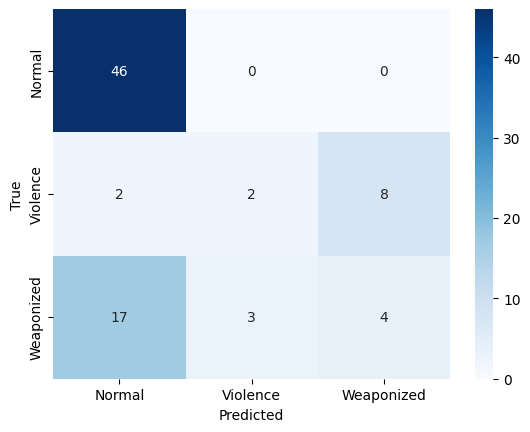

In [15]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()